In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Series tek boyutlu dizilerdir.
seri = pd.Series([1,2,3,4,np.nan,6,8])
seri

,0
0,1.0
1,2.0
2,3.0
3,4.0
4,NaN
5,6.0
6,8.0


In [ ]:
indexes = pd.date_range('20250501',periods=7)
indexes

DatetimeIndex(['2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
               '2025-05-05', '2025-05-06', '2025-05-07'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
#Dataframeler iki boyutlu tablolardir.
pd.DataFrame(np.random.randint(-10,10,size=(7,4)),index=indexes)

,0,1,2,3
2025-05-01,-5,8,1,0
2025-05-02,4,8,-6,-1
2025-05-03,7,-10,3,-1
2025-05-04,-1,-3,-9,-10
2025-05-05,7,-2,3,9
2025-05-06,5,0,-2,-3
2025-05-07,-7,-4,7,-7


In [ ]:
columns = pd.Series(['A','B','C','D'])
columns

,0
0,A
1,B
2,C
3,D


In [ ]:
df = pd.DataFrame(np.random.randint(-10,10,size=(7,4)),index=indexes,columns=columns )
df

,A,B,C,D
2025-05-01,-6,7,1,2
2025-05-02,6,3,9,-1
2025-05-03,8,5,-10,-6
2025-05-04,5,-8,-3,-2
2025-05-05,-1,-7,-3,-6
2025-05-06,-5,9,-4,-2
2025-05-07,-10,-8,0,5


In [ ]:
df2 = pd.DataFrame({
    'A':1,
    'B':pd.date_range('20250501',periods=4),
    'C':pd.Series(1,index=list(range(4)),dtype='float32'),
    'D':np.array([3]*4,dtype='int32'),
    'E':pd.Categorical(['True','False','True','False'])
})

df2

,A,B,C,D,E
0,1,2025-05-01,1.0,3,True
1,1,2025-05-02,1.0,3,False
2,1,2025-05-03,1.0,3,True
3,1,2025-05-04,1.0,3,False


In [ ]:
df2.dtypes

,0
A,int64
B,datetime64[ns]
C,float32
D,int32
E,category


In [ ]:
df2.index

Index([0, 1, 2, 3], dtype='int64')

In [ ]:
df2.columns

Index(['A', 'B', 'C', 'D', 'E'], dtype='object')

In [ ]:
df2.columns =list('abcde')
df2

,a,b,c,d,e
0,1,2025-05-01,1.0,3,True
1,1,2025-05-02,1.0,3,False
2,1,2025-05-03,1.0,3,True
3,1,2025-05-04,1.0,3,False


In [ ]:
#NumPy dizileri tüm dizi için bir veri türüne sahipken pandas DataFrame'leri sütun başına bir veri türüne sahiptir .

df2.to_numpy()

array([[1, Timestamp('2025-05-01 00:00:00'), 1.0, 3, 'True'],
       [1, Timestamp('2025-05-02 00:00:00'), 1.0, 3, 'False'],
       [1, Timestamp('2025-05-03 00:00:00'), 1.0, 3, 'True'],
       [1, Timestamp('2025-05-04 00:00:00'), 1.0, 3, 'False']],
      dtype=object)

In [ ]:
#ascending = artan
#satirda indeks degerlerine gore sirlama
df2.sort_index(axis=0,ascending=False)

,a,b,c,d,e
3,1,2025-05-04,1.0,3,False
2,1,2025-05-03,1.0,3,True
1,1,2025-05-02,1.0,3,False
0,1,2025-05-01,1.0,3,True


In [ ]:
#kolonlara gore siralama
df2.sort_index(axis=1,ascending=False)

,e,d,c,b,a
0,True,3,1.0,2025-05-01,1
1,False,3,1.0,2025-05-02,1
2,True,3,1.0,2025-05-03,1
3,False,3,1.0,2025-05-04,1


In [ ]:
df2.sort_values(by='b',ascending=False)

,a,b,c,d,e
3,1,2025-05-04,1.0,3,False
2,1,2025-05-03,1.0,3,True
1,1,2025-05-02,1.0,3,False
0,1,2025-05-01,1.0,3,True


In [ ]:
df2['a'],df2.a

(0    1
 1    1
 2    1
 3    1
 Name: a, dtype: int64,
 0    1
 1    1
 2    1
 3    1
 Name: a, dtype: int64)

In [ ]:
#pozisyona gore secim
#2. ve 3. satirlari sec
df2.iloc[[2,3]]

,a,b,c,d,e
2,1,2025-05-03,1.0,3,True
3,1,2025-05-04,1.0,3,False


In [ ]:
df2.iloc[[2,3]][['b','e']]

,b,e
2,2025-05-03,True
3,2025-05-04,False


In [ ]:
df2.iloc[[2,3],:3]

,a,b,c
2,1,2025-05-03,1.0
3,1,2025-05-04,1.0


In [ ]:
np.random.seed(1)

df2.d = np.random.randint(-10,10,size=4)
df2

,a,b,c,d,e
0,1,2025-05-01,1.0,-5,True
1,1,2025-05-02,1.0,1,False
2,1,2025-05-03,1.0,2,True
3,1,2025-05-04,1.0,-2,False


In [ ]:
#True ve 2 ifadesinin bulundugu hucreler
df2[df2.isin(['True',2])]

,a,b,c,d,e
0,NaN,NaT,NaN,NaN,True
1,NaN,NaT,NaN,NaN,NaN
2,NaN,NaT,NaN,2.0,True
3,NaN,NaT,NaN,NaN,NaN


In [ ]:
df2.iat[0,2]= 10
df2


,a,b,c,d,e
0,1,2025-05-01,10.0,-5,True
1,1,2025-05-02,1.0,1,False
2,1,2025-05-03,1.0,2,True
3,1,2025-05-04,1.0,-2,False


In [ ]:
df2.at[1,'c'] = 11
df2

,a,b,c,d,e
0,1,2025-05-01,10.0,-5,True
1,1,2025-05-02,11.0,1,False
2,1,2025-05-03,1.0,2,True
3,1,2025-05-04,1.0,-2,False


In [ ]:
df2

,a,b,c,d,e
0,1,2025-05-01,10.0,-5,True
1,1,2025-05-02,11.0,1,False
2,1,2025-05-03,1.0,2,True
3,1,2025-05-04,1.0,-2,False


In [ ]:
#data missing
df2.reindex(columns=['a','b','c','d','e','f'])

,a,b,c,d,e,f
0,1,2025-05-01,10.0,-5,True,NaN
1,1,2025-05-02,11.0,1,False,NaN
2,1,2025-05-03,1.0,2,True,NaN
3,1,2025-05-04,1.0,-2,False,NaN


In [ ]:
df2.reindex(index=[4,3,2,1])

,a,b,c,d,e
4,NaN,NaT,NaN,NaN,NaN
3,1.0,2025-05-04,1.0,-2.0,False
2,1.0,2025-05-03,1.0,2.0,True
1,1.0,2025-05-02,11.0,1.0,False


In [ ]:
#sadece numerik olanlarin ortalamasini al
df2.mean(numeric_only=True)

,0
a,1.00
c,5.75
d,-1.00


In [ ]:
df2.mean(axis=1,numeric_only=True)

,0
0,2.000000
1,4.333333
2,1.333333
3,0.000000


In [ ]:
df2.e.value_counts()

,count
e,
False,2
True,2


In [ ]:
df2['f'] = df2.e.str.lower()
df2['g'] = "oran : " + df2.d.astype(str)
df2

,a,b,c,d,e,f,g
0,1,2025-05-01,10.0,-5,True,true,oran : -5
1,1,2025-05-02,11.0,1,False,false,oran : 1
2,1,2025-05-03,1.0,2,True,true,oran : 2
3,1,2025-05-04,1.0,-2,False,false,oran : -2


In [ ]:
np.random.seed(1)

s1 = pd.Series(np.random.randint(-10, 10, size=4))
s2 = pd.Series(np.random.randint(-10, 10, size=4))
s3 = pd.Series(np.random.randint(-10, 10, size=4))
s1,s2,s3

(0   -5
 1    1
 2    2
 3   -2
 dtype: int64,
 0   -1
 1    1
 2   -5
 3    5
 dtype: int64,
 0   -10
 1     6
 2    -9
 3     2
 dtype: int64)

In [ ]:
#yeni kolonlar ekle
df2.loc[:,'f'] = s1
df2.loc[:,'g'] = s2
df2.loc[:,'h'] = s3
df2

,a,b,c,d,e,f,g,h
0,1,2025-05-01,10.0,-5,True,-5,-1,-10
1,1,2025-05-02,11.0,1,False,1,1,6
2,1,2025-05-03,1.0,2,True,2,-5,-9
3,1,2025-05-04,1.0,-2,False,-2,5,2


In [ ]:
#sifirdan kucukleri pozitife cevirelim
filtre = df2.loc[:,['a','c','d','f','g','h']] <  0
filtre

,a,c,d,f,g,h
0,False,False,True,True,True,True
1,False,False,False,False,False,False
2,False,False,False,False,True,True
3,False,False,True,True,False,False


In [ ]:
df2[filtre] = -df2.loc[:,['a','c','d','f','g','h']]
df2

,a,b,c,d,e,f,g,h
0,1,2025-05-01,10.0,5,True,5,1,10
1,1,2025-05-02,11.0,1,False,1,1,6
2,1,2025-05-03,1.0,2,True,2,5,9
3,1,2025-05-04,1.0,2,False,2,5,2


In [ ]:
#Eksik verilerle  calisma
np.random.seed(1)
choices = list(np.random.randint(-10,10,size=8))
choices.append(np.nan)
choices

[np.int64(-5),
 np.int64(1),
 np.int64(2),
 np.int64(-2),
 np.int64(-1),
 np.int64(1),
 np.int64(-5),
 np.int64(5),
 nan]

In [ ]:
np.random.seed(2)
df2['i'] = np.random.choice(choices,size=4)
df2

,a,b,c,d,e,f,g,h,i
0,1,2025-05-01,10.0,5,True,5,1,10,NaN
1,1,2025-05-02,11.0,1,False,1,1,6,NaN
2,1,2025-05-03,1.0,2,True,2,5,9,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2,2.0


In [ ]:
#bos satirlari sil
df2.dropna()

,a,b,c,d,e,f,g,h,i
2,1,2025-05-03,1.0,2,True,2,5,9,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2,2.0


In [ ]:
#Bos hucrelerin bulundugu sutunlar silinir
df2.dropna(axis=1)

,a,b,c,d,e,f,g,h
0,1,2025-05-01,10.0,5,True,5,1,10
1,1,2025-05-02,11.0,1,False,1,1,6
2,1,2025-05-03,1.0,2,True,2,5,9
3,1,2025-05-04,1.0,2,False,2,5,2


In [ ]:
#Bos hucrelerin bulundugu satirlar silinir
df2.dropna(axis=0)

,a,b,c,d,e,f,g,h,i
2,1,2025-05-03,1.0,2,True,2,5,9,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2,2.0


In [ ]:
df2.dropna(thresh=3)

,a,b,c,d,e,f,g,h,i
0,1,2025-05-01,10.0,5,True,5,1,10,NaN
1,1,2025-05-02,11.0,1,False,1,1,6,NaN
2,1,2025-05-03,1.0,2,True,2,5,9,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2,2.0


In [ ]:
df2.loc[0,'g'] = np.nan
df2.loc[1,'g'] = np.nan
df2.loc[2,'h'] = np.nan
df2

,a,b,c,d,e,f,g,h,i
0,1,2025-05-01,10.0,5,True,5,NaN,10.0,NaN
1,1,2025-05-02,11.0,1,False,1,NaN,6.0,NaN
2,1,2025-05-03,1.0,2,True,2,5,NaN,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2.0,2.0


In [ ]:
#satirda en az gecerli 8 deger varsa silinmesin
df2.dropna(thresh=8,axis=0)

,a,b,c,d,e,f,g,h,i
2,1,2025-05-03,1.0,2,True,2,5,NaN,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2.0,2.0


In [ ]:
#sutunda en az gecerli 3 deger varsa silinmesin
df2.dropna(thresh=3,axis=1)

,a,b,c,d,e,f,h
0,1,2025-05-01,10.0,5,True,5,10.0
1,1,2025-05-02,11.0,1,False,1,6.0
2,1,2025-05-03,1.0,2,True,2,NaN
3,1,2025-05-04,1.0,2,False,2,2.0


In [ ]:
#i sutununa gore kontrol et
df2.dropna(subset=['i'])

,a,b,c,d,e,f,g,h,i
2,1,2025-05-03,1.0,2,True,2,5,NaN,-5.0
3,1,2025-05-04,1.0,2,False,2,5,2.0,2.0


In [ ]:
#b ve e sutunlarini sil
df3 = df2.drop(['b','e'],axis=1)
df3

,a,c,d,f,g,h,i
0,1,10.0,5,5,NaN,10.0,NaN
1,1,11.0,1,1,NaN,6.0,NaN
2,1,1.0,2,2,5,NaN,-5.0
3,1,1.0,2,2,5,2.0,2.0


In [ ]:
df3.fillna(value=5)

<ipython-input-138-4d2ec99d6fae>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3.fillna(value=5)


,a,c,d,f,g,h,i
0,1,10.0,5,5,5,10.0,5.0
1,1,11.0,1,1,5,6.0,5.0
2,1,1.0,2,2,5,5.0,-5.0
3,1,1.0,2,2,5,2.0,2.0


In [ ]:
df3

,a,c,d,f,g,h,i
0,1,10.0,5,5,NaN,10.0,NaN
1,1,11.0,1,1,NaN,6.0,NaN
2,1,1.0,2,2,5,NaN,-5.0
3,1,1.0,2,2,5,2.0,2.0


In [ ]:
df4 = df3.copy()
df4[df4.isna()] = 0
df4

,a,c,d,f,g,h,i
0,1,10.0,5,5,0,10.0,0.0
1,1,11.0,1,1,0,6.0,0.0
2,1,1.0,2,2,5,0.0,-5.0
3,1,1.0,2,2,5,2.0,2.0


In [ ]:
df4.iloc[0,0] = np.nan
df4.iloc[1,2] = np.nan
df4.iloc[3,3] = np.nan
df4

,a,c,d,f,g,h,i
0,NaN,10.0,5.0,5,0,10.0,0.0
1,1.0,11.0,NaN,1,0,6.0,0.0
2,1.0,1.0,2.0,2,5,0.0,-5.0
3,1.0,1.0,2.0,NaN,5,2.0,2.0


In [ ]:
# prompt: df4 veri çerçevesi kullanılıyor: satirlarda kac  tane Nan deger oldugunu hesapla

# Calculate the number of NaN values in each row
row_nan_counts = df4.isnull().sum(axis=1)
row_nan_counts

,0
0,1
1,1
2,0
3,1


In [ ]:
#mean tum sutunlarin ortalamasini alir sonrasinda tum ortalamalarinda
# ortalamasi alinir.
#boylece bos olan hucrelere genel ortalama atanir.
df5 = df3.copy()
df5[df5.isna()] = df5.mean().mean()
df5

,a,c,d,f,g,h,i
0,1,10.0,5,5,3.035714,10.000000,3.035714
1,1,11.0,1,1,3.035714,6.000000,3.035714
2,1,1.0,2,2,5,3.035714,-5.000000
3,1,1.0,2,2,5,2.000000,2.000000


In [ ]:
df3

,a,c,d,f,g,h,i
0,1,10.0,5,5,NaN,10.0,NaN
1,1,11.0,1,1,NaN,6.0,NaN
2,1,1.0,2,2,5,NaN,-5.0
3,1,1.0,2,2,5,2.0,2.0


## Ders Plani
1. groupby kullanimi
2. agg kullanimi
3. merge kullanimi
4. transform kullanimi
5. concat kullanimi
6. pivot tablosu kullanimi
7. tablonun csv olarak kaydedilmesi

In [ ]:
df3.agg(['mean','max','min'])

,a,c,d,f,g,h,i
mean,1.0,5.75,2.5,2.5,5.0,6.0,-1.5
max,1.0,11.00,5.0,5.0,5.0,10.0,2.0
min,1.0,1.00,1.0,1.0,5.0,2.0,-5.0


In [ ]:
#sutunlarda max - min degeri
df3.agg(lambda x: x.max() - x.min())

,0
a,0.0
c,10.0
d,4.0
f,4.0
g,0.0
h,8.0
i,7.0


In [ ]:
#transform genelde gruplarda kullanilir.

df3.transform(lambda x: x * 1.2)

,a,c,d,f,g,h,i
0,1.2,12.000000,6.0,6.0,NaN,12.0,NaN
1,1.2,13.200001,1.2,1.2,NaN,7.2,NaN
2,1.2,1.200000,2.4,2.4,6.0,NaN,-6.0
3,1.2,1.200000,2.4,2.4,6.0,2.4,2.4


In [ ]:
s = pd.Series([1,2,3,4,5,4,5,4,2])
s

,0
0,1
1,2
2,3
3,4
4,5
5,4
6,5
7,4
8,2


In [ ]:
#frekans degerlerini ogreniriz
s.value_counts()

,count
4,3
5,2
2,2
1,1
3,1


In [ ]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
s

,0
0,A
1,B
2,C
3,Aaba
4,Baca
5,NaN
6,CABA
7,dog
8,cat


In [ ]:
s.str.lower()

,0
0,a
1,b
2,c
3,aaba
4,baca
5,NaN
6,caba
7,dog
8,cat


In [ ]:
np.random.seed(1)
df = pd.DataFrame(np.random.randint(-10, 10, size=(10, 4)))

df

,0,1,2,3
0,-5,1,2,-2
1,-1,1,-5,5
2,-10,6,-9,2
3,-3,3,-4,8
4,-5,8,1,0
5,4,8,-6,-1
6,7,-10,3,-1
7,-1,-3,-9,-10
8,7,-2,3,9
9,5,0,-2,-3


In [ ]:
p1,p2,p3 = df[:3], df[3:7], df[7:]
p1

,0,1,2,3
0,-5,1,2,-2
1,-1,1,-5,5
2,-10,6,-9,2


In [ ]:
p2

,0,1,2,3
3,-3,3,-4,8
4,-5,8,1,0
5,4,8,-6,-1
6,7,-10,3,-1


In [ ]:
p3

,0,1,2,3
7,-1,-3,-9,-10
8,7,-2,3,9
9,5,0,-2,-3


In [ ]:
pd.concat([p1,p2,p3])

,0,1,2,3
0,-5,1,2,-2
1,-1,1,-5,5
2,-10,6,-9,2
3,-3,3,-4,8
4,-5,8,1,0
5,4,8,-6,-1
6,7,-10,3,-1
7,-1,-3,-9,-10
8,7,-2,3,9
9,5,0,-2,-3


In [ ]:
#Merge islemi sql join gibi calisir

df1 = pd.DataFrame({
    'id': [1, 2, 3],
    'isim': ['Ali', 'Ayşe', 'Mehmet']
})


df2 = pd.DataFrame({
    'id': [2, 3, 4],
    'maas': [5000, 6000, 7000]
})

sonuc = pd.merge(df1, df2, on='id', how='inner')
sonuc


,id,isim,maas
0,2,Ayşe,5000
1,3,Mehmet,6000


In [ ]:
sonuc = pd.merge(df1, df2, on='id', how='outer')
sonuc


,id,isim,maas
0,1,Ali,NaN
1,2,Ayşe,5000.0
2,3,Mehmet,6000.0
3,4,NaN,7000.0


In [ ]:
sonuc = pd.merge(df1, df2, on='id', how='left')
sonuc


,id,isim,maas
0,1,Ali,NaN
1,2,Ayşe,5000.0
2,3,Mehmet,6000.0


In [ ]:
sonuc = pd.merge(df1, df2, on='id', how='right')
sonuc


,id,isim,maas
0,2,Ayşe,5000
1,3,Mehmet,6000
2,4,NaN,7000


In [ ]:
list1 = ["foo", "bar"]
list2 = ["one", "two"]

np.random.seed(1)
arr1 =  np.random.choice(list1, size=8)
arr2 =  np.random.choice(list2, size=8)

df = pd.DataFrame({
    'A': arr1,
    'B': arr2,
    'C': np.random.randint(-10, 10, size=8),
    'D': np.random.randint(-10, 10, size=8)
})


df

,A,B,C,D
0,bar,two,-4,-6
1,bar,one,8,-1
2,foo,one,-5,7
3,foo,two,8,-10
4,bar,one,1,3
5,bar,two,0,-1
6,bar,two,4,-1
7,bar,one,8,-3


In [ ]:
#Gruplama
np.random.seed(1)
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randint(-10, 10,size=8),
        "D": np.random.randint(-10, 10,size=8),
    }
)

df

,A,B,C,D
0,foo,one,-5,-10
1,bar,one,1,6
2,foo,two,2,-9
3,bar,three,-2,2
4,foo,two,-1,-3
5,bar,two,1,3
6,foo,one,-5,-4
7,foo,three,5,8


In [ ]:
#A kolonuna gore grupla
grup = pd.DataFrame(df.groupby('A'))
grup

,0,1
0,bar,A B C D 1 bar one 1 6 3 bar...
1,foo,A B C D 0 foo one -5 -10 2 f...


In [ ]:
#gruplar
grup[0]

,0
0,bar
1,foo


In [ ]:
#gruplarin elemanlari
grup[1]

,1
0,A B C D 1 bar one 1 6 3 bar...
1,A B C D 0 foo one -5 -10 2 f...


In [ ]:
#bar grubu
grup[1][0]

,A,B,C,D
1,bar,one,1,6
3,bar,three,-2,2
5,bar,two,1,3


In [ ]:
#foo grubu
grup[1][1]

,A,B,C,D
0,foo,one,-5,-10
2,foo,two,2,-9
4,foo,two,-1,-3
6,foo,one,-5,-4
7,foo,three,5,8


In [ ]:
#kategorik veriyi sayisala cevir
for i,name in enumerate(grup[1][1].B.unique(),start=1):
    grup[1][1].loc[grup[1][1].B == name,'E'] = i

grup[1][1]

,A,B,C,D,E
0,foo,one,-5,-10,1.0
2,foo,two,2,-9,2.0
4,foo,two,-1,-3,2.0
6,foo,one,-5,-4,1.0
7,foo,three,5,8,3.0


```python
import pandas as pd
import numpy as np

# Örnek Veri Seti
data = {
    'Bölge': ['Doğu', 'Batı', 'Doğu', 'Kuzey', 'Batı', 'Doğu', 'Kuzey'],
    'Ürün Türü': ['Elektronik', 'Giyim', 'Giyim', 'Elektronik', 'Elektronik', 'Giyim', 'Giyim'],
    'Miktar': [5, 10, 3, 8, 2, 7, 12],
    'Satış': [1000, 500, 150, 1600, 400, 350, 600]
}
df = pd.DataFrame(data)
print("Orijinal DataFrame:\n", df)

print("\n--- Pandas Pivot Tablo Kullanımı ---")

# Örnek 1: Her Bölgenin Toplam Satışı (aggfunc=sum varsayılan değil, belirtilmeli)
# index='Bölge' ile satırları bölgelere göre grupla
# values='Satış' ile Satış sütununu özetle
# aggfunc='sum' ile toplamı al
pivot_1 = pd.pivot_table(df, index='Bölge', values='Satış', aggfunc='sum')
print("\n1. Her Bölgenin Toplam Satışı:\n", pivot_1)
# Çıktı:
#           Satış
# Bölge
# Batı        900
# Doğu       1500
# Kuzey      2200

# Örnek 2: Her Ürün Türünün Ortalama Miktarı (varsayılan aggfunc='mean')
# index='Ürün Türü' ile satırları ürün türlerine göre grupla
# values='Miktar' ile Miktar sütununu özetle
pivot_2 = pd.pivot_table(df, index='Ürün Türü', values='Miktar') # aggfunc varsayılan 'mean'
print("\n2. Her Ürün Türünün Ortalama Miktarı:\n", pivot_2)
# Çıktı:
#             Miktar
# Ürün Türü
# Elektronik     5.0
# Giyim          8.0

# Örnek 3: Bölge ve Ürün Türüne Göre Toplam Satış ve Ortalama Miktar
# index=['Bölge'] ile satırları bölgelere göre grupla
# columns=['Ürün Türü'] ile sütunları ürün türlerine göre grupla
# values=['Satış', 'Miktar'] ile hem Satış hem Miktar sütunlarını özetle
# aggfunc={'Satış': 'sum', 'Miktar': 'mean'} ile farklı sütunlara farklı fonksiyonlar
pivot_3 = pd.pivot_table(df,
                         index='Bölge',
                         columns='Ürün Türü',
                         values=['Satış', 'Miktar'],
                         aggfunc={'Satış': 'sum', 'Miktar': 'mean'},
                         fill_value=0) # NaN değerleri 0 ile doldur
print("\n3. Bölge ve Ürün Türüne Göre Toplam Satış ve Ortalama Miktar:\n", pivot_3)
# Çıktı:
#              Miktar            Satış
# Ürün Türü Elektronik Giyim Elektronik Giyim
# Bölge
# Batı             2.0  10.0      400   500
# Doğu             5.0   5.0     1000   500
# Kuzey            8.0  12.0     1600   600

# Örnek 4: Toplamlar (margins=True) ile pivot tablo
pivot_4 = pd.pivot_table(df,
                         index='Bölge',
                         columns='Ürün Türü',
                         values='Satış',
                         aggfunc='sum',
                         margins=True, # Satır ve sütun toplamlarını ekler
                         fill_value=0)
print("\n4. Toplamlar ile Bölge ve Ürün Türüne Göre Toplam Satış:\n", pivot_4)
# Çıktı:
# Ürün Türü  Elektronik  Giyim  All
# Bölge
# Batı              400    500  900
# Doğu             1000    500 1500
# Kuzey            1600    600 2200
# All              3000   1600 4600

# Örnek 5: Farklı fonksiyonları tek bir sütun için uygulama
pivot_5 = pd.pivot_table(df,
                         index='Bölge',
                         values='Satış',
                         aggfunc=[np.sum, np.mean, np.max])
print("\n5. Bölgeye Göre Satış için birden fazla fonksiyon:\n", pivot_5)
# Çıktı:
#        sum   mean   amax
# Bölge
# Batı   900  450.0    500
# Doğu  1500  500.0   1000
# Kuzey 2200 1100.0   1600
```

In [ ]:
#A kolonuna gore gruplanan tabloda
#C ve D sutunlarinin ortalamasi
df.groupby('A')[['C','D']].mean()

,C,D
A,,
bar,0.0,3.666667
foo,-0.8,-3.600000


In [ ]:
df

,A,B,C,D
0,foo,one,-5,-10
1,bar,one,1,6
2,foo,two,2,-9
3,bar,three,-2,2
4,foo,two,-1,-3
5,bar,two,1,3
6,foo,one,-5,-4
7,foo,three,5,8


<Axes: >

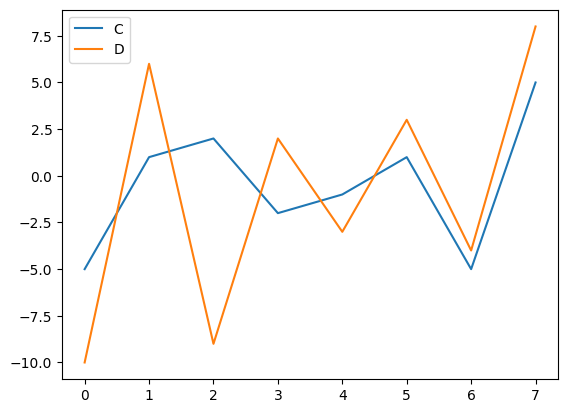

In [ ]:
df.plot()

<Axes: xlabel='A'>

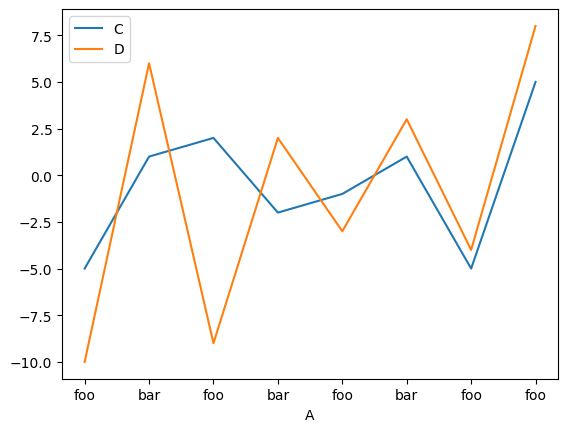

In [ ]:
#x eksenine A sutununu yerlestir
df.plot(x='A')

<Axes: xlabel='B'>

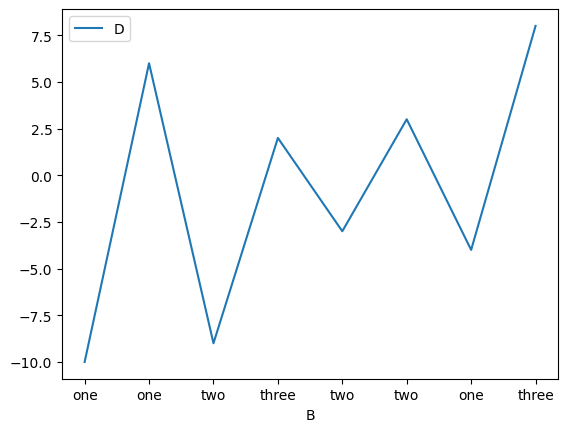

In [ ]:
df.plot(x='B',y='D')

<Axes: ylabel='Frequency'>

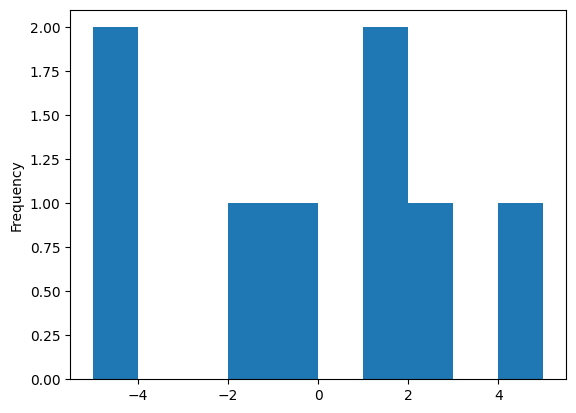

In [ ]:
df.C.plot.hist()

<Axes: >

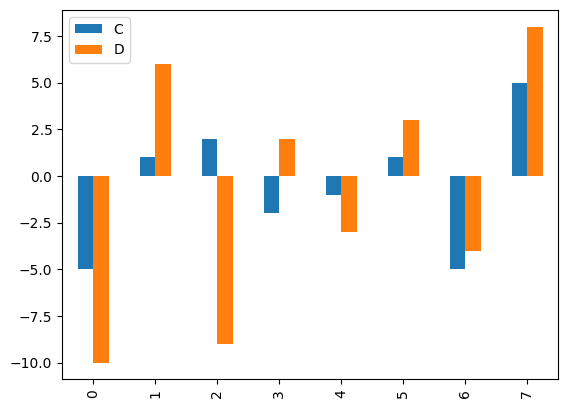

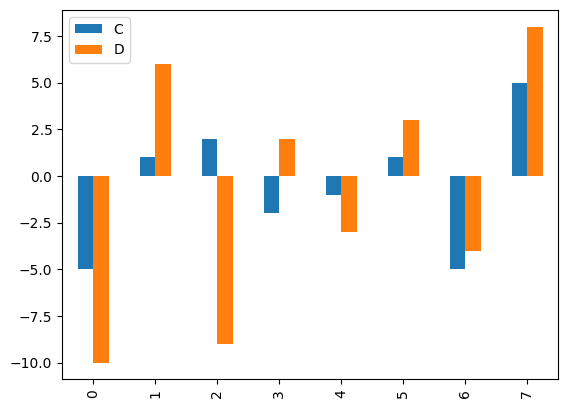

In [ ]:
df.plot(kind='bar')
df.plot.bar()